## Reversibility main effect

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
from statsmodels.stats.contingency_tables import Table

import seaborn as sns

# Overall Subgroup:

1. Contigency Table
2. Proportions
3. Chi-Square Test
4. Expected Counts
5. Cramér's V
6. Standardized Residuals
7. Interpretation

Read data

In [2]:
subgroup_theoretical = pd.read_csv("../../data/processed/subgroup_theoretical.csv")

1. Contingency Table

In [3]:
contingency = pd.crosstab(
    [subgroup_theoretical["Consequent_Reversibility"], subgroup_theoretical["Goal_Type"]],
    subgroup_theoretical["Response_Full"]
)

contingency

Response_Full                               L1_transfer  L2_other  correct
Consequent_Reversibility Goal_Type                                        
No                       goal_non_frequent           37        10       19
Yes                      goal_frequent               25        16       24
                         no_goal                     34        12       18

2. Proportions

In [4]:
proportions = pd.crosstab(
    [subgroup_theoretical["Consequent_Reversibility"],subgroup_theoretical["Goal_Type"]],
    subgroup_theoretical["Response_Full"],
    normalize="index"
)

proportions

Response_Full                               L1_transfer  L2_other   correct
Consequent_Reversibility Goal_Type                                         
No                       goal_non_frequent     0.560606  0.151515  0.287879
Yes                      goal_frequent         0.384615  0.246154  0.369231
                         no_goal               0.531250  0.187500  0.281250

3. Chi-Square Test

In [5]:
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square: {chi2:.3f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square: 4.882
p-value: 0.2996
Degrees of freedom: 4


Is there evidence that response distribution differs across reversibility conditions?
No, there is no evidence that response distribution differs across reversibility conditions.

4. Expected Counts

In [6]:
expected_df = pd.DataFrame(
    expected,
    index=contingency.index,
    columns=contingency.columns
)

expected_df

Response_Full                               L1_transfer   L2_other    correct
Consequent_Reversibility Goal_Type                                           
No                       goal_non_frequent    32.492308  12.861538  20.646154
Yes                      goal_frequent        32.000000  12.666667  20.333333
                         no_goal              31.507692  12.471795  20.020513

In [7]:
print(expected_df < 5)

Response_Full                               L1_transfer  L2_other  correct
Consequent_Reversibility Goal_Type                                        
No                       goal_non_frequent        False     False    False
Yes                      goal_frequent            False     False    False
                         no_goal                  False     False    False


There aren't any groups with fewer than 5 observations.

5. Cramér's V

In [8]:
n = contingency.values.sum()

cramers_v = np.sqrt(
    chi2 / (n * (min(contingency.shape) - 1))
)

print(f"Cramér's V: {cramers_v:.3f}")

Cramér's V: 0.112


V = 0.104: the effect size is small

6. Standardized Residuals

In [9]:
residuals = (
    contingency - expected
) / np.sqrt(expected)

residuals

Response_Full                               L1_transfer  L2_other   correct
Consequent_Reversibility Goal_Type                                         
No                       goal_non_frequent     0.790795 -0.797909 -0.362285
Yes                      goal_frequent        -1.237437  0.936586  0.813143
                         no_goal               0.444011 -0.133595 -0.451569

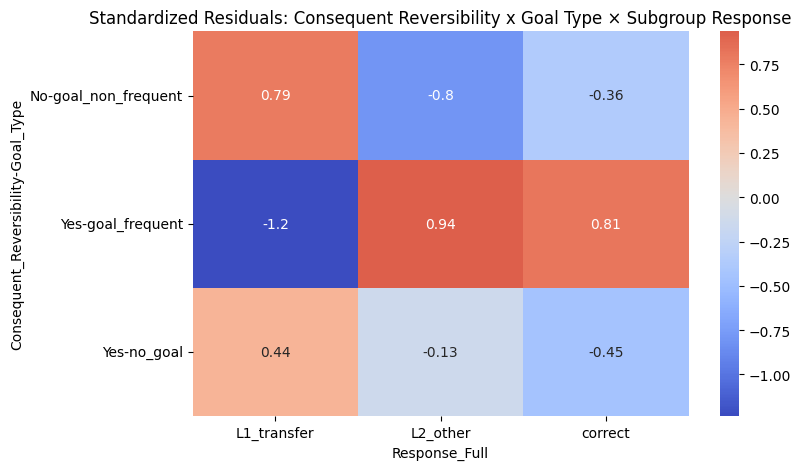

In [10]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    residuals,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Residuals: Consequent Reversibility x Goal Type × Subgroup Response")
plt.show()

7. Interpretation

Interpretation:

- χ² significant / not significant
- Effect size
- Cells driving the association
- Does this support the reversibility hypothesis?
- What remains unexplained?

Although residuals suggest a tendency for irreversible scenarios to elicit more L1-transfer responses than expected and reversible scenarios to elicit fewer, the overall association between Consequent Reversibility and response type is weak and non-significant (χ²(2)=2.11, p=.35, Cramér’s V=.10).

Therefore, Consequent Reversibility on its own cannot account for response distribution in the theoretical subgroup.

This suggests that the effect of reversibility may depend on additional contextual variables like Agency and/or Goal Type.

# Actors Subgroup:

1. Contigency Table
2. Proportions
3. Chi-Square Test
4. Expected Counts
5. Cramér's V
6. Standardized Residuals
7. Interpretation

Read data

In [11]:
subgroup_actors = subgroup_theoretical[subgroup_theoretical["Focus"] == "I"].copy()

1. Contingency Table

In [12]:
contingency = pd.crosstab(
    [subgroup_actors["Consequent_Reversibility"], subgroup_actors["Goal_Type"]],
    subgroup_actors["Response_Full"]
)

contingency

Response_Full                               L1_transfer  L2_other  correct
Consequent_Reversibility Goal_Type                                        
No                       goal_non_frequent           18         9       13
Yes                      goal_frequent               13        10       16
                         no_goal                     22         5       11

2. Proportions

In [13]:
proportions = pd.crosstab(
    [subgroup_actors["Consequent_Reversibility"],subgroup_actors["Goal_Type"]],
    subgroup_actors["Response_Full"],
    normalize="index"
)

proportions

Response_Full                               L1_transfer  L2_other   correct
Consequent_Reversibility Goal_Type                                         
No                       goal_non_frequent     0.450000  0.225000  0.325000
Yes                      goal_frequent         0.333333  0.256410  0.410256
                         no_goal               0.578947  0.131579  0.289474

3. Chi-Square Test

In [14]:
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square: {chi2:.3f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square: 5.015
p-value: 0.2857
Degrees of freedom: 4


4. Expected Counts

In [15]:
expected_df = pd.DataFrame(
    expected,
    index=contingency.index,
    columns=contingency.columns
)

expected_df

Response_Full                               L1_transfer  L2_other    correct
Consequent_Reversibility Goal_Type                                          
No                       goal_non_frequent    18.119658  8.205128  13.675214
Yes                      goal_frequent        17.666667  8.000000  13.333333
                         no_goal              17.213675  7.794872  12.991453

In [16]:
print(expected_df < 5)

Response_Full                               L1_transfer  L2_other  correct
Consequent_Reversibility Goal_Type                                        
No                       goal_non_frequent        False     False    False
Yes                      goal_frequent            False     False    False
                         no_goal                  False     False    False


There are no groups with fewer than  observations

5. Cramér's V

In [17]:
n = contingency.values.sum()

cramers_v = np.sqrt(
    chi2 / (n * (min(contingency.shape) - 1))
)

print(f"Cramér's V: {cramers_v:.3f}")

Cramér's V: 0.146


V = 0.038: the effect size is tiny, even smaller than the effect size for the overal subgroup (V = 0.104)

6. Standardized Residuals

In [18]:
residuals = (
    contingency - expected
) / np.sqrt(expected)

residuals

Response_Full                               L1_transfer  L2_other   correct
Consequent_Reversibility Goal_Type                                         
No                       goal_non_frequent    -0.028110  0.277495 -0.182589
Yes                      goal_frequent        -1.110272  0.707107  0.730297
                         no_goal               1.153627 -1.001054 -0.552511

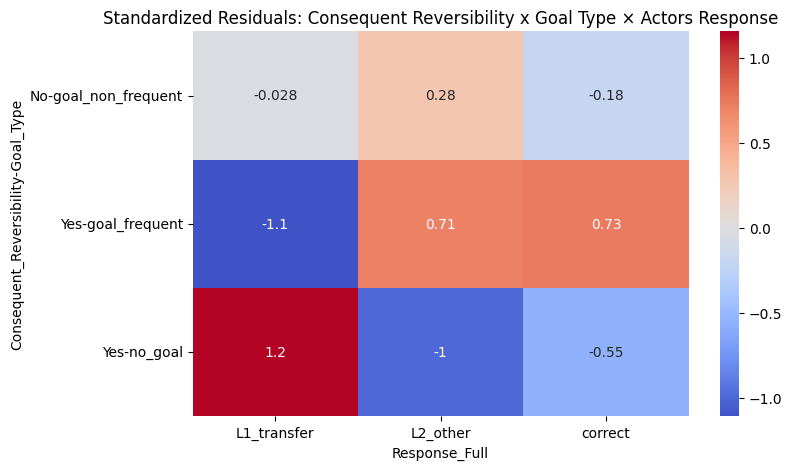

In [19]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    residuals,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Residuals: Consequent Reversibility x Goal Type × Actors Response")
plt.show()

7. Interpretation

Neither the overall theoretical subgroup nor the actors subgroup showed a significant association between Consequent Reversibility and response type. Effect sizes were small to negligible (V = .104 and V = .038 respectively). Standardized residuals revealed no meaningful departures from expected frequencies among actors. These findings indicate that reversibility alone does not account for response choice and suggest that any potential influence of reversibility may emerge only in interaction with other theoretically relevant variables such as Agency and Goal Type. 

**Consequent Reversability is not a main effect.**
